## Uncertainty example

\begin{align}
        p(\textbf{z}|c) &= \mathcal{C}_d(\kappa)\exp\left(\kappa\mu^T_{c}\textbf{z}\right)\\
        \mathcal{C}_d(\kappa) &= \frac{(\kappa)^{d/2-1}}{(2\pi)^{d/2}\mathcal{I}_{d/2-1}(\kappa)}
\end{align}

With d=2:

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from notebooks.circle_plot_utils import (
    get_vectors_by_angle,
    draw_circle,
    draw_dencity,
    draw_example,
)

%load_ext autoreload
%autoreload 2

In [4]:
# draw_example(
#     kappa=15,
#     gallery_class_angles=[0.4, 0.25],
#     text_shift=[[-0.2, -0.3], [-0.2, 0.1]],
#     save_name="test.png",
# )

### False Identification example

In [5]:
# draw_example(kappa = 15, gallery_class_angles = [0.4, 0.25], text_shift = [[-0.2, -0.3], [-0.2, 0.1]], save_name='/app/paper_assets/images/false_ident_example.png')

### False accept/reject example

In [6]:
# draw_example(kappa = 13, gallery_class_angles = [0.48, 0.25], text_shift = [[-0.1, -0.3], [-0.35, 0.2]], save_name='/app/paper_assets/images/false_accept-reject_example.png')

## Monte Carlo sampling

In [8]:
from evaluation.samplers import random_VMF, VonMisesFisher

gallery_features = []  # N gallery samples X 512
gallery_unc_log = []  # N gallery samples X 1
gallery_subject_ids_sorted = []  # N gallery samples


class_center_angles = np.array([0, np.pi / 2, np.pi])
class_z_kappa = np.array([9, 6, 5])
colors = list(mcolors.TABLEAU_COLORS)[: len(class_center_angles)]


rng = np.random.default_rng(2)

for class_id, (angle, kappa) in enumerate(zip(class_center_angles, class_z_kappa)):
    num_samples = rng.integers(5, 8)
    gallery_subject_ids_sorted.extend([class_id] * num_samples)
    gallery_unc_log.extend(4 * rng.random(num_samples) + 2)
    samples = random_VMF(
        get_vectors_by_angle([angle])[0], kappa=kappa, size=num_samples
    )
    gallery_features.extend(samples)

gallery_features = np.array(gallery_features)
gallery_unc_log = np.array(gallery_unc_log).reshape(-1, 1)
gallery_subject_ids_sorted = np.array(gallery_subject_ids_sorted)

gallery_unc = np.exp(gallery_unc_log)

In [9]:
gallery_features.shape, gallery_subject_ids_sorted.shape

((19, 2), (19,))

In [10]:
sampler = VonMisesFisher(3)
feature_mean = sampler(np.array([[0, 1], [1, 0]]), np.array([[10], [15]]))

/tmp/ipykernel_8937/1737226771.py:34: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


FileNotFoundError: [Errno 2] No such file or directory: '/app/outputs/images/generation.png'

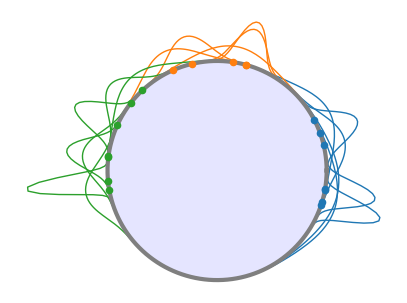

In [ ]:
fontsize = 20
linewidth = 3
dot_size = 80
fig, ax = plt.subplots(figsize=(5, 5))
draw_circle(ax, linewidth)
for class_id, (angle, kappa) in enumerate(zip(class_center_angles, class_z_kappa)):
    color = colors[class_id]
    for position in np.where(gallery_subject_ids_sorted == class_id)[0]:
        point_angle = np.angle(
            [gallery_features[position][0] + 1j * gallery_features[position][1]]
        )[0]
        draw_dencity(
            point_angle,
            gallery_unc[position],
            ax,
            linewidth=1,
            color=color,
            range=np.pi / 2,
            scale=0.1,
            draw_center=True,
            dot_size=20,
        )
fig.gca().set_aspect("equal")
fig.show()
plt.savefig("/app/outputs/images/generation.png", dpi=300, bbox_inches="tight")

### Monte Carlo integration

In [ ]:
import torch

gallery_features.shape
init_mean = np.array(
    [
        np.mean(gallery_features[gallery_subject_ids_sorted == c], axis=0)
        for c in range(3)
    ]
)
# init_mean = init_mean / np.linalg.norm(init_mean, axis=1, keepdims=True)

init_kappa = np.array(
    [np.mean(gallery_unc[gallery_subject_ids_sorted == c], axis=0) for c in range(3)]
)

In [ ]:
gallery_features.shape, gallery_unc.shape

((19, 2), (19, 1))

In [ ]:
from evaluation.open_set_methods.class_prob_models import MonteCarloPredictiveProb

In [ ]:
import geotorch

nll_loss = torch.nn.NLLLoss()


class GalleryParams(torch.nn.Module):
    def __init__(self, init_mean, init_kappa):
        super(GalleryParams, self).__init__()
        self.gallery_means = torch.nn.Parameter(torch.tensor(init_mean))
        # self.gallery_kappas =  torch.nn.Parameter(torch.tensor(init_kappa))
        # self.gallery_means = torch.nn.Parameter(torch.rand(3, 2, dtype=torch.float64))
        self.gallery_kappas = torch.nn.Parameter(
            torch.rand(3, 1, dtype=torch.float64) * 10
        )


gallery_params = GalleryParams(init_mean, init_kappa)
target_class = torch.tensor(gallery_subject_ids_sorted)
T = torch.nn.Parameter(torch.tensor(1.0))
geotorch.sphere(gallery_params, "gallery_means")


# train
M = 10
mc_prob = MonteCarloPredictiveProb(M=M)

# optimizer = torch.optim.Adam([gallery_means, gallery_kappas], lr=10e-3)
optimizer = torch.optim.Adam(gallery_params.parameters(), lr=0.1)

num_steps = 450

for iter in range(num_steps):
    optimizer.zero_grad()
    # compute nll loss
    log_probs = mc_prob(
        gallery_features,
        gallery_unc,
        gallery_params.gallery_means,
        gallery_params.gallery_kappas,
        T,
    )[:, :, :-1]
    probs = torch.exp(log_probs)
    mean_probs = torch.mean(probs, axis=1)
    log_probs_new = torch.log(mean_probs)
    loss = nll_loss(log_probs_new, target_class)
    loss.backward()
    optimizer.step()
    print(gallery_params.gallery_means)
    print(torch.norm(gallery_params.gallery_means, dim=-1))
    print(gallery_params.gallery_kappas)
    print(f"Iteration {iter}, Loss: {loss.item()}")

tensor([[ 0.4201, -0.9075],
        [ 0.9729,  0.2314],
        [ 0.9161,  0.4009]], dtype=torch.float64, grad_fn=<MulBackward0>)
tensor([1.0000, 1.0000, 1.0000], dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)
Parameter containing:
tensor([[2.3080],
        [4.2513],
        [3.9996]], dtype=torch.float64, requires_grad=True)
Iteration 0, Loss: 5.511763690956834
tensor([[ 0.5295, -0.8483],
        [ 0.9414,  0.3373],
        [ 0.8607,  0.5091]], dtype=torch.float64, grad_fn=<MulBackward0>)
tensor([1.0000, 1.0000, 1.0000], dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)
Parameter containing:
tensor([[2.2158],
        [4.1533],
        [3.8996]], dtype=torch.float64, requires_grad=True)
Iteration 1, Loss: 5.319564462862632
tensor([[ 0.6284, -0.7779],
        [ 0.8987,  0.4387],
        [ 0.7926,  0.6098]], dtype=torch.float64, grad_fn=<MulBackward0>)
tensor([1., 1., 1.], dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)
Parameter containing:
ten

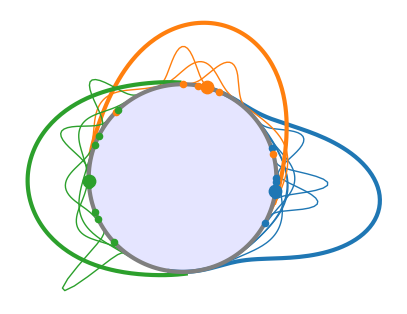

In [ ]:
fontsize = 20
linewidth = 3
dot_size = 80
fig, ax = plt.subplots(figsize=(5, 5))
draw_circle(ax, linewidth)
for class_id, (class_mean, kappa) in enumerate(
    zip(gallery_params.gallery_means, gallery_params.gallery_kappas)
):
    color = colors[class_id]
    class_mean = class_mean.detach().numpy()
    kappa = kappa.detach().numpy()
    class_point_angle = np.angle([class_mean[0] + 1j * class_mean[1]])[0]
    draw_dencity(
        class_point_angle,
        kappa,
        ax,
        linewidth=3,
        color=color,
        range=np.pi / 2,
        draw_center=True,
        dot_size=dot_size,
        type="power",
    )
    for position in np.where(gallery_subject_ids_sorted == class_id)[0]:
        point_angle = np.angle(
            [gallery_features[position][0] + 1j * gallery_features[position][1]]
        )[0]
        draw_dencity(
            point_angle,
            gallery_unc[position],
            ax,
            linewidth=1,
            color=color,
            range=np.pi / 2,
            scale=0.1,
            draw_center=True,
            dot_size=20,
        )
fig.gca().set_aspect("equal")
fig.show()
plt.savefig("/app/outputs/images/trained.png", dpi=300, bbox_inches="tight")

### Test Probability estimation

In [ ]:
test_angles = np.array([np.pi / 3])
test_vectors = get_vectors_by_angle(test_angles)
test_kappa = np.array([[10]])
M = 100
mc_prob = MonteCarloPredictiveProb(M=M)

log_probs = mc_prob(
    test_vectors,
    test_kappa,
    gallery_params.gallery_means,
    gallery_params.gallery_kappas,
    T,
)  # [:, :, :-1]
probs = torch.exp(log_probs)
mean_probs = torch.mean(probs, axis=1)

In [ ]:
mean_probs

tensor([[0.0491, 0.4923, 0.0034, 0.4552]], dtype=torch.float64,
       grad_fn=<MeanBackward1>)

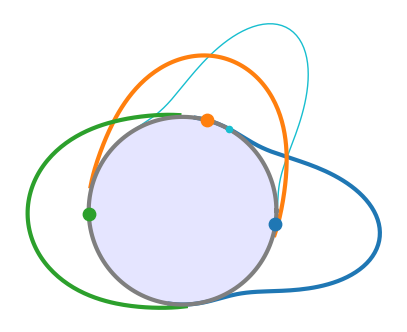

In [ ]:
fontsize = 20
linewidth = 3
dot_size = 80
fig, ax = plt.subplots(figsize=(5, 5))
draw_circle(ax, linewidth)
draw_dencity(
    test_angles[0],
    test_kappa[0],
    ax,
    linewidth=1,
    color="tab:cyan",
    range=np.pi / 2,
    scale=1,
    draw_center=True,
    dot_size=20,
)
for class_id, (class_mean, kappa) in enumerate(
    zip(gallery_params.gallery_means, gallery_params.gallery_kappas)
):
    color = colors[class_id]
    class_mean = class_mean.detach().numpy()
    kappa = kappa.detach().numpy()
    class_point_angle = np.angle([class_mean[0] + 1j * class_mean[1]])[0]
    draw_dencity(
        class_point_angle,
        kappa,
        ax,
        linewidth=3,
        color=color,
        range=np.pi / 2,
        draw_center=True,
        dot_size=dot_size,
        type="power",
    )
fig.gca().set_aspect("equal")
fig.show()
plt.savefig("/app/outputs/images/test.png", dpi=300, bbox_inches="tight")

In [ ]:
colors

['tab:blue', 'tab:orange', 'tab:green']